### Case Study: Supply Chain Analysis & AI Demand Forecasting

**importing all dependencies**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

**loading dataset (from kaggle)**

In [ ]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')

(180519, 53)


**Initial Exploration**

In [4]:
print(df.shape) #number of rows and columns in dataset
print(df.isnull().sum()) #number of missing values in each column

(180519, 53)
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                     

In [ ]:
print(df.describe()) #summary statistics of numerical columns

       Days for shipping (real)  Days for shipment (scheduled)  \
count             180519.000000                  180519.000000   
mean                   3.497654                       2.931847   
std                    1.623722                       1.374449   
min                    0.000000                       0.000000   
25%                    2.000000                       2.000000   
50%                    3.000000                       4.000000   
75%                    5.000000                       4.000000   
max                    6.000000                       4.000000   

       Benefit per order  Sales per customer  Late_delivery_risk  \
count      180519.000000       180519.000000       180519.000000   
mean           21.974989          183.107609            0.548291   
std           104.433526          120.043670            0.497664   
min         -4274.979980            7.490000            0.000000   
25%             7.000000          104.379997            0.000000 

In [ ]:
print(df['Delivery Status'].value_counts()) #counts number of orders for each delivery status

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


In [ ]:
print(df['Market'].value_counts()) #counts number of orders from each market

Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64


In [ ]:
print(df['Shipping Mode'].value_counts()) #counts number of orders for each shipping mode

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [16]:
#Analysis of orders with negative benefit

negative = df[df['Benefit per order'] <0] #variable filters orders with a negative benefit
print(negative[['Product Name', 'Order Item Quantity', 
                'Order Item Discount Rate', 
                'Benefit per order']].head(20)) 
  #prints the first 20 rows of negative benefit orders 

                                      Product Name  Order Item Quantity  \
1                                     Smart watch                     1   
2                                     Smart watch                     1   
15                                    Smart watch                     1   
16                                    Smart watch                     1   
28                                    Smart watch                     1   
33                                    Smart watch                     1   
34                                    Smart watch                     1   
48                Perfect Fitness Perfect Rip Deck                    2   
49   Under Armour Girls' Toddler Spine Surge Runni                    2   
53            Nike Men's Dri-FIT Victory Golf Polo                    2   
59               Nike Men's Free 5.0+ Running Shoe                    3   
61   Glove It Women's Mod Oval 3-Zip Carry All Gol                    3   
75                Perfect

In [15]:
#Average order value by customer segment
segment_value = df.groupby('Customer Segment')['Order Item Total'].mean()
print("Average Order Value by Customer Segment:")
print(segment_value)

Average Order Value by Customer Segment:
Customer Segment
Consumer       183.567317
Corporate      183.077806
Home Office    181.824431
Name: Order Item Total, dtype: float64


**Visuals**

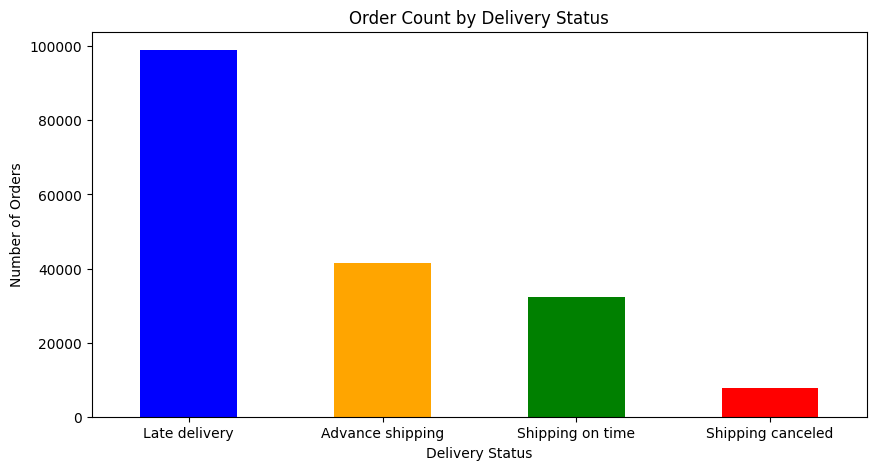

In [ ]:
#Late delivery by status - bar plot

df['Delivery Status'].value_counts().plot(
    kind='bar', 
    color=['blue', 'orange', 'green', 'red'],
    figsize=(10,5),
    title='Order Count by Delivery Status'
)
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

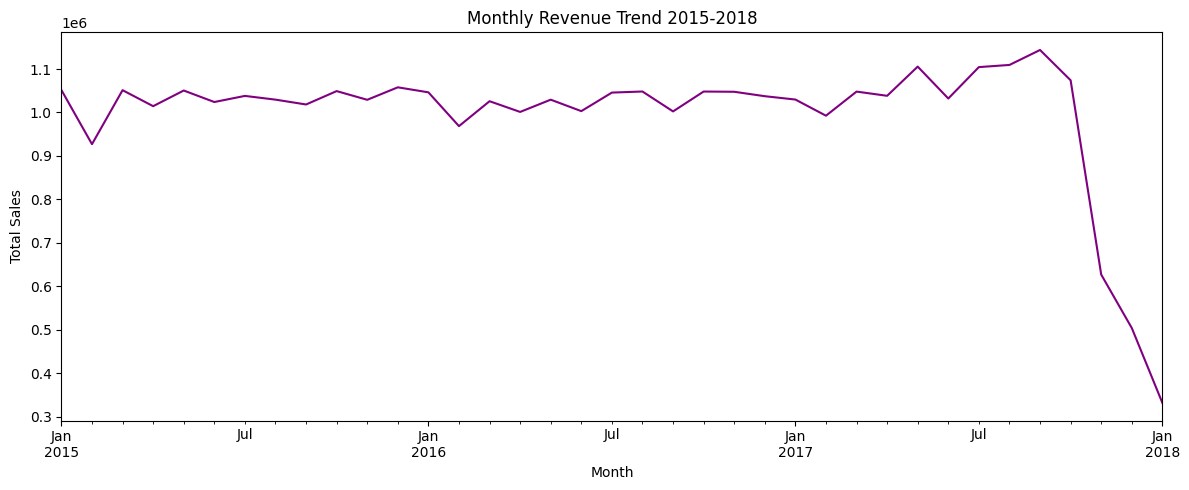

In [ ]:
#Revenue trend from 2015 to 2018 - line plot

df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)']) #convert order date column to datetime format
monthly = df.groupby(df['order date (DateOrders)'].dt.to_period('M'))['Sales'].sum() #group sales by month and sum

monthly.plot(kind='line', figsize=(12,5), title='Monthly Revenue Trend 2015-2018', color='purple')
plt.ylabel('Total Sales')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


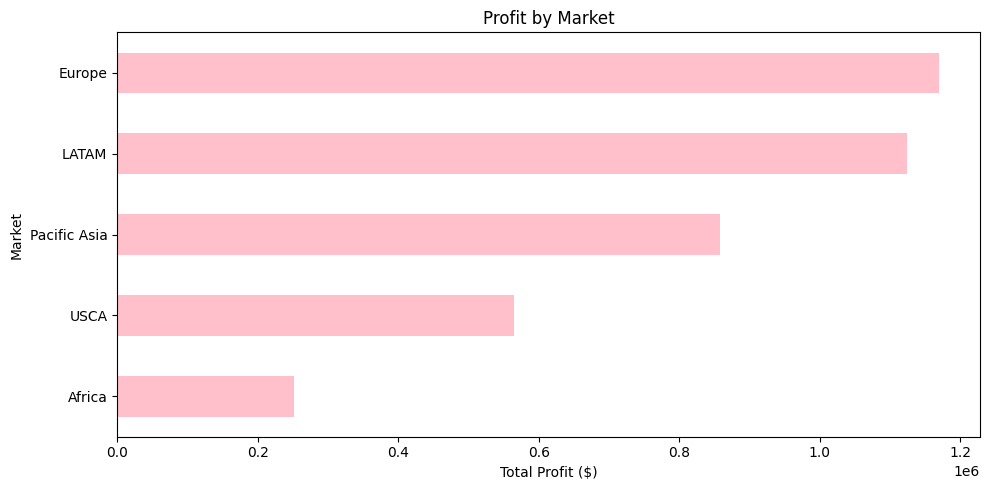

In [ ]:
#Profit by market - horizontal bar plot

market_profit = df.groupby('Market')['Order Profit Per Order'].sum().sort_values() #group profit by market, sum, and sort ascending
market_profit.plot(kind='barh', color='pink', figsize=(10,5), title='Profit by Market') #create horizontal barplot
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.show()